# Data Preprocessing
Prepare the data for model training.

In [204]:
# ================================
# DATA HANDLING
# ================================
import pandas as pd
import numpy as np


# ================================
# VISUALIZATION (optional but useful)
# ================================
import matplotlib.pyplot as plt
import seaborn as sns


# ================================
# SKLEARN PREPROCESSING
# ================================
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)


# ================================
# TRAIN TEST SPLIT
# ================================
from sklearn.model_selection import train_test_split


# ================================
# HANDLE IMBALANCED DATA
# ================================
from imblearn.over_sampling import SMOTE


# ================================
# SAVE PREPROCESSING OBJECTS
# ================================
import joblib


# ================================
# OPTIONAL PIPELINE UTILITIES
# ================================
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [205]:
# Load dataset
df = pd.read_csv("eda_cleaned.csv")
print(df.head())

   Age  Gender         Country self_employed family_history treatment  \
0   37  Female   United States            No             No       Yes   
1   44       M   United States            No             No        No   
2   32    Male          Canada            No             No        No   
3   31    Male  United Kingdom            No            Yes       Yes   
4   31    Male   United States            No             No        No   

  work_interfere    no_employees remote_work tech_company  ...   anonymity  \
0          Often            6-25          No          Yes  ...         Yes   
1         Rarely  More than 1000          No           No  ...  Don't know   
2         Rarely            6-25          No          Yes  ...  Don't know   
3          Often          26-100          No          Yes  ...          No   
4          Never         100-500         Yes          Yes  ...  Don't know   

                leave mental_health_consequence phys_health_consequence  \
0       Somewhat 

In [206]:
df.sample(25)


,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
987,28,male,United Kingdom,No,No,No,Often,6-25,No,Yes,...,No,Somewhat difficult,Yes,No,No,No,No,Yes,Yes,No
296,30,F,United States,No,Yes,Yes,Sometimes,26-100,No,Yes,...,Don't know,Very easy,No,No,Yes,Yes,No,Yes,Yes,No
761,37,Female,United States,No,Yes,Yes,Rarely,26-100,No,No,...,Don't know,Don't know,Maybe,Maybe,Yes,Some of them,No,Maybe,Yes,No
508,47,M,United States,No,Yes,Yes,Sometimes,More than 1000,No,Yes,...,Don't know,Very easy,No,No,Some of them,Yes,No,Yes,Yes,No
636,36,male,Poland,Yes,Yes,Yes,Often,6-25,No,Yes,...,Don't know,Somewhat easy,No,No,Some of them,Yes,Maybe,Maybe,Yes,Yes
126,27,Male,United Kingdom,No,No,No,Unknown,6-25,No,Yes,...,Don't know,Don't know,No,No,Some of them,Some of them,No,No,Don't know,No
629,28,Male,United States,No,Yes,Yes,Sometimes,26-100,Yes,Yes,...,Don't know,Don't know,Yes,No,Some of them,Some of them,No,No,Don't know,Yes
858,33,Male,United States,No,No,No,Unknown,100-500,No,Yes,...,Don't know,Don't know,Maybe,No,Some of them,Yes,No,No,No,No
973,49,Male,United States,No,Yes,No,Never,More than 1000,No,Yes,...,Yes,Don't know,No,No,Yes,Yes,No,No,Yes,No
1167,34,male,Poland,No,No,No,Never,More than 1000,Yes,Yes,...,Don't know,Don't know,Maybe,No,Some of them,Some of them,No,Yes,Don't know,No


In [207]:
df["treatment"].value_counts()

treatment
Yes    637
No     622
Name: count, dtype: int64

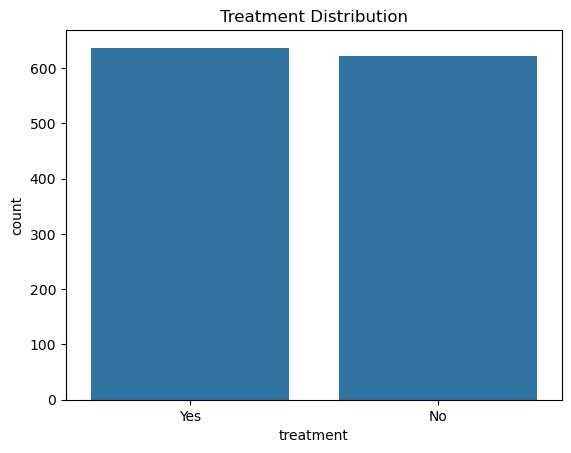

In [208]:
sns.countplot(x="treatment", data=df)

plt.title("Treatment Distribution")
plt.show()

In [209]:
cat_cols = df.select_dtypes(include="object").columns

output_lines = []

for col in cat_cols:

    section = []
    
    section.append("\n" + "=" * 60)
    section.append(f"COLUMN: {col}")
    section.append("=" * 60)

    unique_count = df[col].nunique()

    section.append(f"Unique Values Count: {unique_count}\n")

    value_counts = df[col].value_counts(dropna=False)
    percentages = (
        df[col].value_counts(normalize=True, dropna=False) * 100
    )

    for value, count in value_counts.items():

        percentage = percentages[value]

        section.append(
            f"Value: {value} | "
            f"Count: {count} | "
            f"Percentage: {percentage:.2f}%"
        )

    section.append("\n")

    # Print nicely in notebook/console
    print("\n".join(section))

    # Store for txt file
    output_lines.extend(section)


# =========================================
# SAVE TO TXT FILE
# =========================================
with open(
    "categorical_analysis.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write("\n".join(output_lines))


print("\nCategorical analysis saved successfully!")


COLUMN: Gender
Unique Values Count: 49

Value: Male | Count: 615 | Percentage: 48.85%
Value: male | Count: 206 | Percentage: 16.36%
Value: Female | Count: 121 | Percentage: 9.61%
Value: M | Count: 116 | Percentage: 9.21%
Value: female | Count: 62 | Percentage: 4.92%
Value: F | Count: 38 | Percentage: 3.02%
Value: m | Count: 34 | Percentage: 2.70%
Value: f | Count: 15 | Percentage: 1.19%
Value: Make | Count: 4 | Percentage: 0.32%
Value: Male  | Count: 3 | Percentage: 0.24%
Value: Woman | Count: 3 | Percentage: 0.24%
Value: Cis Male | Count: 2 | Percentage: 0.16%
Value: Man | Count: 2 | Percentage: 0.16%
Value: Female (trans) | Count: 2 | Percentage: 0.16%
Value: Female  | Count: 2 | Percentage: 0.16%
Value: Trans woman | Count: 1 | Percentage: 0.08%
Value: msle | Count: 1 | Percentage: 0.08%
Value: male leaning androgynous | Count: 1 | Percentage: 0.08%
Value: Neuter | Count: 1 | Percentage: 0.08%
Value: cis male | Count: 1 | Percentage: 0.08%
Value: queer | Count: 1 | Percentage: 0.08

In [210]:
binary_cols = [
    "self_employed",
    "family_history",
    "treatment",
    "remote_work",
    "tech_company",
    "obs_consequence"
]

for col in binary_cols:

    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })

In [211]:
df.head()

,Age,Gender,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,...,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence
0,37,Female,United States,0,0,1,Often,6-25,0,1,...,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,0
1,44,M,United States,0,0,0,Rarely,More than 1000,0,0,...,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,0
2,32,Male,Canada,0,0,0,Rarely,6-25,0,1,...,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,0
3,31,Male,United Kingdom,0,1,1,Often,26-100,0,1,...,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,1
4,31,Male,United States,0,0,0,Never,100-500,1,1,...,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,0


In [212]:
df["Gender"] = (
    df["Gender"]
    .str.lower()
    .str.strip()
)


male_keywords = [
    "male",
    "man",
    "cis male",
    "cis man"
]


female_keywords = [
    "female",
    "woman",
    "cis female"
]


def clean_gender(x):

    # clear typo fixes first
    typo_map = {
        "m": "male",
        "mail": "male",
        "malr": "male",
        "maile": "male",
        "make": "male",
        "msle": "male",
        "mal": "male",

        "f": "female",
        "femail": "female",
        "femake": "female"
    }

    if x in typo_map:
        x = typo_map[x]

    # strict semantic grouping
    if any(keyword == x for keyword in male_keywords):
        return "Male"

    elif any(keyword == x for keyword in female_keywords):
        return "Female"

    else:
        return "Other"


df["Gender"] = df["Gender"].apply(clean_gender)

In [213]:
column_name = "Gender"   # change column name here

counts = df[column_name].value_counts(dropna=False)
percentages = (counts / len(df)) * 100

print(f"\nCOLUMN: {column_name}")
print("=" * 50)

for value, count in counts.items():
    print(f"Value: {value} | Count: {count} | Percentage: {percentages[value]:.2f}%")


COLUMN: Gender
Value: Male | Count: 989 | Percentage: 78.55%
Value: Female | Count: 245 | Percentage: 19.46%
Value: Other | Count: 25 | Percentage: 1.99%


In [214]:
cat_cols = df.select_dtypes(include="object").columns

output_lines = []

for col in cat_cols:

    section = []
    
    section.append("\n" + "=" * 60)
    section.append(f"COLUMN: {col}")
    section.append("=" * 60)

    unique_count = df[col].nunique()

    section.append(f"Unique Values Count: {unique_count}\n")

    value_counts = df[col].value_counts(dropna=False)
    percentages = (
        df[col].value_counts(normalize=True, dropna=False) * 100
    )

    for value, count in value_counts.items():

        percentage = percentages[value]

        section.append(
            f"Value: {value} | "
            f"Count: {count} | "
            f"Percentage: {percentage:.2f}%"
        )

    section.append("\n")

    # Print nicely in notebook/console
    print("\n".join(section))

    # Store for txt file
    output_lines.extend(section)


# =========================================
# SAVE TO TXT FILE
# =========================================
with open(
    "categorical_analysis2.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write("\n".join(output_lines))


print("\nCategorical analysis saved successfully!")


COLUMN: Gender
Unique Values Count: 3

Value: Male | Count: 989 | Percentage: 78.55%
Value: Female | Count: 245 | Percentage: 19.46%
Value: Other | Count: 25 | Percentage: 1.99%



COLUMN: Country
Unique Values Count: 48

Value: United States | Count: 751 | Percentage: 59.65%
Value: United Kingdom | Count: 185 | Percentage: 14.69%
Value: Canada | Count: 72 | Percentage: 5.72%
Value: Germany | Count: 45 | Percentage: 3.57%
Value: Ireland | Count: 27 | Percentage: 2.14%
Value: Netherlands | Count: 27 | Percentage: 2.14%
Value: Australia | Count: 21 | Percentage: 1.67%
Value: France | Count: 13 | Percentage: 1.03%
Value: India | Count: 10 | Percentage: 0.79%
Value: New Zealand | Count: 8 | Percentage: 0.64%
Value: Poland | Count: 7 | Percentage: 0.56%
Value: Switzerland | Count: 7 | Percentage: 0.56%
Value: Sweden | Count: 7 | Percentage: 0.56%
Value: Italy | Count: 7 | Percentage: 0.56%
Value: South Africa | Count: 6 | Percentage: 0.48%
Value: Belgium | Count: 6 | Percentage: 0.48%
Valu

In [215]:
one_hot_cols = [
    "Gender",
    "care_options",
    "benefits",
    "wellness_program"
]

df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=False
)

In [216]:
seek_help_map = {
    "No": 0,
    "Don't know": 1,
    "Yes": 2
}

df["seek_help"] = df["seek_help"].map(seek_help_map)

In [217]:
df.head()

,Age,Country,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,seek_help,...,Gender_Other,care_options_No,care_options_Not sure,care_options_Yes,benefits_Don't know,benefits_No,benefits_Yes,wellness_program_Don't know,wellness_program_No,wellness_program_Yes
0,37,United States,0,0,1,Often,6-25,0,1,2,...,False,False,True,False,False,False,True,False,True,False
1,44,United States,0,0,0,Rarely,More than 1000,0,0,1,...,False,True,False,False,True,False,False,True,False,False
2,32,Canada,0,0,0,Rarely,6-25,0,1,0,...,False,True,False,False,False,True,False,False,True,False
3,31,United Kingdom,0,1,1,Often,26-100,0,1,0,...,False,False,False,True,False,True,False,False,True,False
4,31,United States,0,0,0,Never,100-500,1,1,1,...,False,True,False,False,False,False,True,True,False,False


In [218]:
cat_cols = df.select_dtypes(include="object").columns

output_lines = []

for col in cat_cols:

    section = []
    
    section.append("\n" + "=" * 60)
    section.append(f"COLUMN: {col}")
    section.append("=" * 60)

    unique_count = df[col].nunique()

    section.append(f"Unique Values Count: {unique_count}\n")

    value_counts = df[col].value_counts(dropna=False)
    percentages = (
        df[col].value_counts(normalize=True, dropna=False) * 100
    )

    for value, count in value_counts.items():

        percentage = percentages[value]

        section.append(
            f"Value: {value} | "
            f"Count: {count} | "
            f"Percentage: {percentage:.2f}%"
        )

    section.append("\n")

    # Print nicely in notebook/console
    print("\n".join(section))

    # Store for txt file
    output_lines.extend(section)


# =========================================
# SAVE TO TXT FILE
# =========================================
with open(
    "categorical_analysis3.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write("\n".join(output_lines))


print("\nCategorical analysis saved successfully!")


COLUMN: Country
Unique Values Count: 48

Value: United States | Count: 751 | Percentage: 59.65%
Value: United Kingdom | Count: 185 | Percentage: 14.69%
Value: Canada | Count: 72 | Percentage: 5.72%
Value: Germany | Count: 45 | Percentage: 3.57%
Value: Ireland | Count: 27 | Percentage: 2.14%
Value: Netherlands | Count: 27 | Percentage: 2.14%
Value: Australia | Count: 21 | Percentage: 1.67%
Value: France | Count: 13 | Percentage: 1.03%
Value: India | Count: 10 | Percentage: 0.79%
Value: New Zealand | Count: 8 | Percentage: 0.64%
Value: Poland | Count: 7 | Percentage: 0.56%
Value: Switzerland | Count: 7 | Percentage: 0.56%
Value: Sweden | Count: 7 | Percentage: 0.56%
Value: Italy | Count: 7 | Percentage: 0.56%
Value: South Africa | Count: 6 | Percentage: 0.48%
Value: Belgium | Count: 6 | Percentage: 0.48%
Value: Brazil | Count: 6 | Percentage: 0.48%
Value: Israel | Count: 5 | Percentage: 0.40%
Value: Singapore | Count: 4 | Percentage: 0.32%
Value: Bulgaria | Count: 4 | Percentage: 0.32%


In [219]:
work_interfere_map = {
    "Never": 0,
    "Rarely": 1,
    "Sometimes": 2,
    "Often": 3,
    "Unknown": -1
}

df["work_interfere"] = df["work_interfere"].map(work_interfere_map)

In [220]:
no_employees_map = {
    "1-5": 0,
    "6-25": 1,
    "26-100": 2,
    "100-500": 3,
    "500-1000": 4,
    "More than 1000": 5
}

df["no_employees"] = df["no_employees"].map(no_employees_map)

In [221]:
df = pd.get_dummies(df, columns=['anonymity'])

In [222]:
leave_map = {
    'Very easy': 0,
    'Somewhat easy': 1,
    "Don't know": 2,
    'Somewhat difficult': 3,
    'Very difficult': 4
}

df['leave'] = df['leave'].map(leave_map)

In [223]:
mental_health_consequence_map = {
    "No": 0,
    "Maybe": 1,
    "Yes": 2
}

df["mental_health_consequence"] = df[
    "mental_health_consequence"
].map(mental_health_consequence_map)

In [224]:
phys_health_consequence_map = {
    "No": 0,
    "Maybe": 1,
    "Yes": 2
}

df["phys_health_consequence"] = df[
    "phys_health_consequence"
].map(phys_health_consequence_map)

In [225]:
coworkers_map = {
    "No": 0,
    "Some of them": 1,
    "Yes": 2
}

df["coworkers"] = df["coworkers"].map(coworkers_map)

In [226]:
supervisor_map = {
    "No": 0,
    "Some of them": 1,
    "Yes": 2
}

df["supervisor"] = df["supervisor"].map(supervisor_map)

In [227]:
phys_health_interview_map = {
    "No": 0,
    "Maybe": 1,
    "Yes": 2
}

df["phys_health_interview"] = df[
    "phys_health_interview"
].map(phys_health_interview_map)

In [228]:
mental_health_interview_map = {
    'No': 0,
    'Maybe': 1,
    'Yes': 2
}

df['mental_health_interview'] = df['mental_health_interview'].map(
    mental_health_interview_map
)

In [229]:
df = pd.get_dummies(df, columns=['mental_vs_physical'])

In [230]:
print(df.dtypes)

Age                               int64
Country                          object
self_employed                     int64
family_history                    int64
treatment                         int64
work_interfere                    int64
no_employees                      int64
remote_work                       int64
tech_company                      int64
seek_help                         int64
leave                             int64
mental_health_consequence         int64
phys_health_consequence           int64
coworkers                         int64
supervisor                        int64
mental_health_interview           int64
phys_health_interview             int64
obs_consequence                   int64
Gender_Female                      bool
Gender_Male                        bool
Gender_Other                       bool
care_options_No                    bool
care_options_Not sure              bool
care_options_Yes                   bool
benefits_Don't know                bool


In [231]:
western_developed = [
    "United States",
    "United Kingdom",
    "Canada",
    "Germany",
    "Ireland",
    "Netherlands",
    "Australia",
    "France",
    "New Zealand",
    "Switzerland",
    "Sweden",
    "Italy",
    "Belgium",
    "Austria",
    "Finland",
    "Denmark",
    "Norway"
]


developed_asia_pacific = [
    "Japan",
    "Singapore",
    "Israel"
]


developing = [
    "India",
    "Brazil",
    "South Africa",
    "Mexico",
    "Nigeria",
    "Thailand",
    "Philippines",
    "Bulgaria",
    "Romania",
    "Russia",
    "Colombia",
    "Croatia",
    "Portugal",
    "China"
]


def group_country(x):

    if x in western_developed:
        return "Western_Developed"

    elif x in developed_asia_pacific:
        return "Developed_Asia_Pacific"

    elif x in developing:
        return "Developing"

    else:
        return "Other"


# =========================================
# CREATE GROUPED COUNTRY FEATURE
# =========================================
df["Country_Group"] = df["Country"].apply(group_country)


# =========================================
# DROP ORIGINAL COUNTRY COLUMN
# =========================================
df.drop(columns=["Country"], inplace=True)


# =========================================
# ONE HOT ENCODE GROUPED COUNTRY
# =========================================
df = pd.get_dummies(
    df,
    columns=["Country_Group"],
    drop_first=False
)

In [232]:
df.sample(15)

,Age,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,seek_help,leave,...,anonymity_Don't know,anonymity_No,anonymity_Yes,mental_vs_physical_Don't know,mental_vs_physical_No,mental_vs_physical_Yes,Country_Group_Developed_Asia_Pacific,Country_Group_Developing,Country_Group_Other,Country_Group_Western_Developed
1045,26,0,1,1,2,3,0,1,0,2,...,False,False,True,True,False,False,False,False,False,True
1035,35,0,1,0,2,1,1,1,0,2,...,True,False,False,True,False,False,False,False,False,True
788,37,0,0,0,-1,3,1,0,1,1,...,True,False,False,True,False,False,False,False,False,True
426,24,0,1,1,2,3,0,1,0,3,...,True,False,False,False,True,False,False,False,False,True
953,36,0,1,1,1,1,0,1,1,2,...,True,False,False,True,False,False,False,False,False,True
664,30,0,0,0,2,5,0,0,0,0,...,False,False,True,True,False,False,False,False,False,True
248,32,0,1,1,2,0,1,1,0,2,...,True,False,False,True,False,False,False,False,False,True
1039,35,0,0,0,-1,1,1,1,0,2,...,True,False,False,True,False,False,False,False,False,True
1086,41,0,0,1,2,5,0,1,0,3,...,True,False,False,False,False,True,False,False,False,True
838,43,0,1,0,-1,5,0,0,0,0,...,True,False,False,True,False,False,False,False,False,True


In [233]:
X = df.drop("treatment", axis=1)
y = df["treatment"]

In [234]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.13,
    random_state=42,
    stratify=y
)

In [235]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [236]:
print(X_train_scaled[:5])

[[-0.02897211 -0.36059806 -0.80258591  1.45933356  1.52120106  1.50297324
  -2.10256797 -0.86930525 -0.65088762 -1.07704723 -0.56923194  0.04122527
   1.06165823  1.53795268  0.35099375 -0.40607095  2.02899542 -1.89758803
  -0.14969624  1.23883906 -0.56926521 -0.75118953 -0.68973998 -0.65251916
   1.28006024 -0.40759561  0.69406921 -0.47271946  0.73785417 -0.23215938
  -0.65678958  1.08088706 -0.60161474 -0.6128851  -0.09103457 -0.18437553
  -0.12927912  0.24707592]
 [ 0.22850178 -0.36059806  1.24597253 -0.01480874 -0.24270486 -0.66534784
   0.47560888 -0.86930525  2.10448071  1.52067681  2.96226368  0.04122527
  -1.30599097 -0.46449463 -1.06201417  2.46262383 -0.49285473  0.52698477
  -0.14969624  1.23883906 -0.56926521 -0.75118953 -0.68973998  1.53252206
  -0.78121323 -0.40759561  0.69406921 -0.47271946  0.73785417 -0.23215938
  -0.65678958 -0.92516604  1.66219331 -0.6128851  -0.09103457 -0.18437553
  -0.12927912  0.24707592]
 [-0.17610005 -0.36059806 -0.80258591  1.45933356 -0.83067

In [237]:
import joblib

joblib.dump(
    scaler,
    "standard_scaler.pkl"
)

['standard_scaler.pkl']

In [238]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

In [239]:
X_train_scaled.to_csv(
    "processed_data/X_train_scaled.csv",
    index=False
)


In [240]:
X_test_scaled.to_csv(
    "processed_data/X_test_scaled.csv",
    index=False
)

In [241]:
y_train.to_csv(
    "processed_data/y_train.csv",
    index=False
)

In [242]:
y_test.to_csv(
    "processed_data/y_test.csv",
    index=False
)